# Yield Curve Prophet

## Why This Matters

The yield curve is the single most watched indicator in fixed income. Its shape dictates portfolio positioning, relative value trades, and macro regime classification. Every basis point move in the 2Y or 10Y triggers billions in hedging flow.

Most yield forecasting on Wall Street is still discretionary - PMs read the dot plot, watch payrolls, and make a call. This notebook asks whether a machine can do better than a coin flip at predicting the *direction* of weekly yield moves.

We build three classifiers - one for the 2Y (front-end, Fed-sensitive), one for the 10Y (term premium, growth expectations), and one for the 2s10s spread (curve shape, recession signal). Each model sees 60 trading days of macro history and predicts whether the next 5 trading days will move up or down.

**The ensemble (LSTM + XGBoost) lets us answer two questions:**
1. Does temporal sequence matter, or is today's snapshot sufficient? (LSTM vs XGBoost)
2. Can we beat 50%? By how much, and in which regimes?

All data is free via the FRED API. No Bloomberg required.

In [1]:
import os
import warnings
import time
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

import xgboost as xgb
import optuna
import shap
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    classification_report, roc_curve,
)
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

FRED_API_KEY = os.environ["FRED_API_KEY"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch device: {DEVICE}")
print(f"Setup complete.")
from sklearn.calibration import calibration_curve


PyTorch device: cpu
Setup complete.


In [2]:
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

def fetch_fred_series(series_id: str, start: str = "2004-01-01",
                      end: str = "2025-12-31") -> pd.Series:
    """Pull a single FRED series and return as a pandas Series with datetime index."""
    params = {
        "series_id": series_id,
        "api_key": FRED_API_KEY,
        "file_type": "json",
        "observation_start": start,
        "observation_end": end,
    }
    resp = requests.get(BASE_URL, params=params)
    resp.raise_for_status()
    data = resp.json()["observations"]
    df = pd.DataFrame(data)
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    series = df.set_index("date")["value"].dropna()
    series.name = series_id
    time.sleep(0.1)
    return series


FRED_SERIES = [
    ("DGS2", "2Y Treasury Yield", "daily"),
    ("DGS5", "5Y Treasury Yield", "daily"),
    ("DGS10", "10Y Treasury Yield", "daily"),
    ("DGS30", "30Y Treasury Yield", "daily"),
    ("DFF", "Fed Funds Effective Rate", "daily"),
    ("T10YIE", "10Y Breakeven Inflation", "daily"),
    ("T5YIFR", "5Y5Y Forward Inflation", "daily"),
    ("UNRATE", "Unemployment Rate", "monthly"),
    ("ICSA", "Initial Jobless Claims", "weekly"),
    ("INDPRO", "Industrial Production Index", "monthly"),
    ("UMCSENT", "Consumer Sentiment", "monthly"),
    ("VIXCLS", "CBOE VIX", "daily"),
    ("DTWEXBGS", "Trade-Weighted Dollar Index", "daily"),
    ("BAMLH0A0HYM2", "HY OAS", "daily"),
]

TRAIN_END = "2018-12-31"
VAL_END = "2020-12-31"

LOOKBACK = 60
HORIZON = 5
TARGETS = ["dgs2_dir", "dgs10_dir", "spread_2s10s_dir"]
TARGET_LABELS = {
    "dgs2_dir": "2Y Yield Direction",
    "dgs10_dir": "10Y Yield Direction",
    "spread_2s10s_dir": "2s10s Spread Direction",
}

print(f"Configured {len(FRED_SERIES)} FRED series")
print(f"Train: 2005 - {TRAIN_END}")
print(f"Val: {TRAIN_END} - {VAL_END}")
print(f"Test: {VAL_END} - 2025")

Configured 14 FRED series
Train: 2005 - 2018-12-31
Val: 2018-12-31 - 2020-12-31
Test: 2020-12-31 - 2025


## 2. Data Collection

Pull all FRED series, align to a common daily trading calendar, and forward-fill lower-frequency series (monthly, weekly) to daily.

In [3]:
print("Pulling FRED data...")
print("=" * 50)

raw_series = {}
for series_id, desc, freq in FRED_SERIES:
    try:
        s = fetch_fred_series(series_id)
        raw_series[series_id] = s
        print(f"  {series_id:20s} | {desc:35s} | {len(s):,} obs | {s.index[0].date()} to {s.index[-1].date()}")
    except Exception as e:
        print(f"  {series_id:20s} | FAILED: {e}")

print(f"\nPulled {len(raw_series)} / {len(FRED_SERIES)} series successfully.")

Pulling FRED data...


  DGS2                 | 2Y Treasury Yield                   | 5,503 obs | 2004-01-02 to 2025-12-31


  DGS5                 | 5Y Treasury Yield                   | 5,503 obs | 2004-01-02 to 2025-12-31


  DGS10                | 10Y Treasury Yield                  | 5,503 obs | 2004-01-02 to 2025-12-31


  DGS30                | 30Y Treasury Yield                  | 5,503 obs | 2004-01-02 to 2025-12-31


...

  INDPRO               | Industrial Production Index         | 264 obs | 2004-01-01 to 2025-12-01


  UMCSENT              | Consumer Sentiment                  | 264 obs | 2004-01-01 to 2025-12-01


  VIXCLS               | CBOE VIX                            | 5,563 obs | 2004-01-02 to 2025-12-31


  DTWEXBGS             | Trade-Weighted Dollar Index         | 5,013 obs | 2006-01-02 to 2025-12-31


  BAMLH0A0HYM2         | HY OAS                              | 684 obs | 2023-05-23 to 2025-12-31

Pulled 14 / 14 series successfully.


In [4]:
trading_days = raw_series["DGS10"].index

df = pd.DataFrame(index=trading_days)
for series_id, s in raw_series.items():
    df[series_id] = s.reindex(df.index)

# Forward-fill lower-frequency series
df = df.ffill()
df = df.loc["2005-01-01":]

# Drop series with <50% coverage (e.g., TEDRATE discontinued, BAMLH0A0HYM2 limited)
coverage = df.notna().mean()
sparse_cols = coverage[coverage < 0.5].index.tolist()
if sparse_cols:
    print(f"Dropping sparse series (<50% coverage): {sparse_cols}")
    df = df.drop(columns=sparse_cols)
    # Also remove from FRED_SERIES list so feature engineering skips them
    FRED_SERIES[:] = [(s, d, f) for s, d, f in FRED_SERIES if s not in sparse_cols]

# Now drop rows with remaining NaNs (only at the very start)
df = df.dropna()

print(f"Aligned dataset: {df.shape[0]:,} trading days x {df.shape[1]} series")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print()
print("Missing values per series:")
print(df.isnull().sum())


Dropping sparse series (<50% coverage): ['ICSA', 'BAMLH0A0HYM2']
Aligned dataset: 5,003 trading days x 12 series
Date range: 2006-01-03 to 2025-12-31

Missing values per series:
DGS2        0
DGS5        0
DGS10       0
DGS30       0
DFF         0
T10YIE      0
T5YIFR      0
UNRATE      0
INDPRO      0
UMCSENT     0
VIXCLS      0
DTWEXBGS    0
dtype: int64


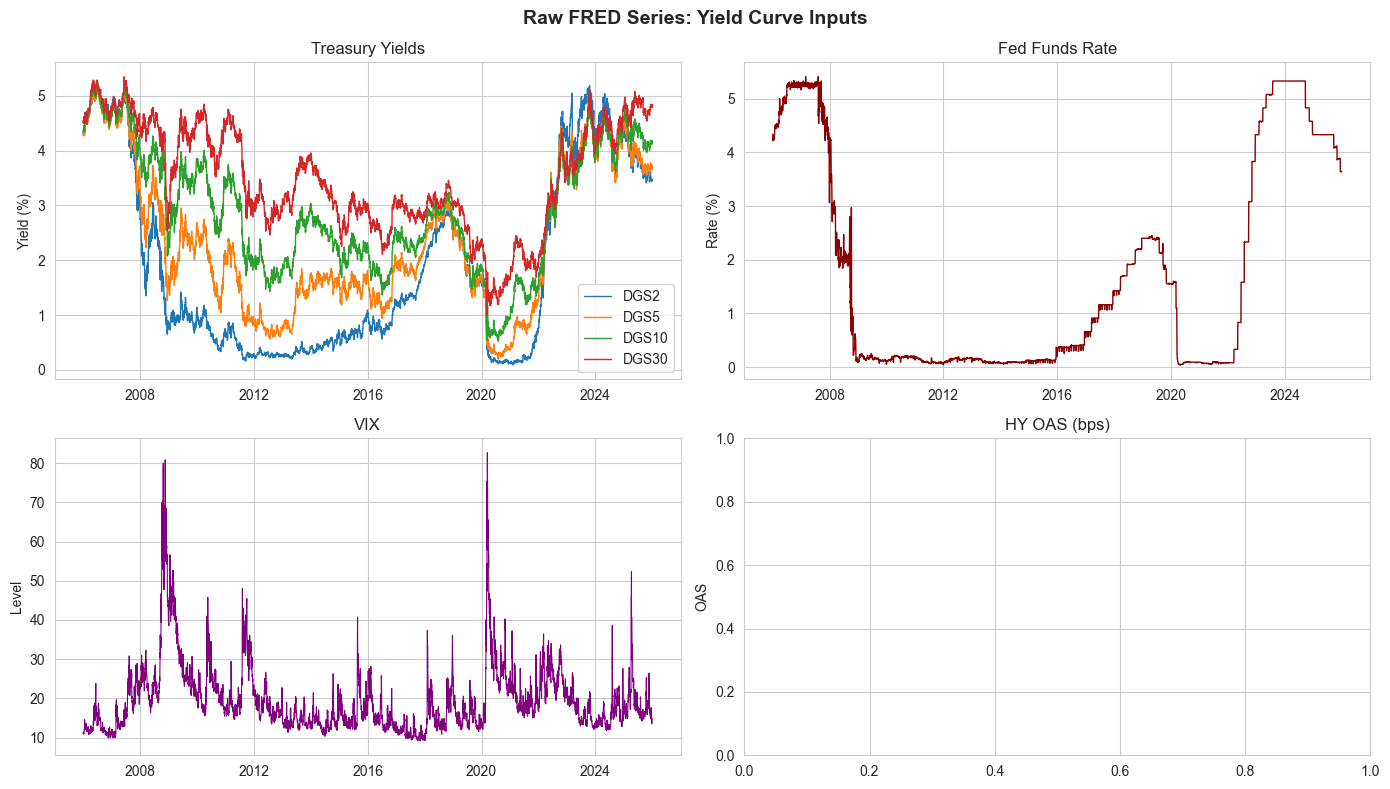

Saved: raw_fred_series.png


In [5]:
assert df.shape[0] > 4000, f"Expected ~5000 trading days, got {df.shape[0]}"
assert df.isnull().sum().sum() == 0, "No NaNs should remain after ffill + dropna"
assert "DGS2" in df.columns and "DGS10" in df.columns, "Must have 2Y and 10Y yields"

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Raw FRED Series: Yield Curve Inputs", fontsize=14, fontweight="bold")

ax = axes[0, 0]
for tenor in ["DGS2", "DGS5", "DGS10", "DGS30"]:
    ax.plot(df.index, df[tenor], label=tenor, linewidth=1)
ax.set_title("Treasury Yields")
ax.set_ylabel("Yield (%)")
ax.legend()

ax = axes[0, 1]
ax.plot(df.index, df["DFF"], color="darkred", linewidth=1)
ax.set_title("Fed Funds Rate")
ax.set_ylabel("Rate (%)")

ax = axes[1, 0]
ax.plot(df.index, df["VIXCLS"], color="purple", linewidth=0.8)
ax.set_title("VIX")
ax.set_ylabel("Level")

ax = axes[1, 1]
if "BAMLH0A0HYM2" in df.columns:
    ax.plot(df.index, df["BAMLH0A0HYM2"], color="orange", linewidth=1)
ax.set_title("HY OAS (bps)")
ax.set_ylabel("OAS")

plt.tight_layout()
plt.savefig("raw_fred_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: raw_fred_series.png")

## 3. Feature Engineering

For each raw series, compute rolling changes (5d, 21d, 63d), realized volatility (21d), z-scores (vs 252d rolling mean), and momentum signals. Also derive curve spreads (2s10s, 5s30s, real 10Y).

Total features: ~80-100 after engineering.

In [6]:
df["spread_2s10s"] = df["DGS10"] - df["DGS2"]
df["spread_5s30s"] = df["DGS30"] - df["DGS5"]
df["real_10y"] = df["DGS10"] - df["T10YIE"]

print("Derived series added: spread_2s10s, spread_5s30s, real_10y")
print(f"Current 2s10s: {df['spread_2s10s'].iloc[-1]:.2f}%")
print(f"Current real 10Y: {df['real_10y'].iloc[-1]:.2f}%")

Derived series added: spread_2s10s, spread_5s30s, real_10y
Current 2s10s: 0.71%
Current real 10Y: 1.93%


In [7]:
def engineer_features(df: pd.DataFrame, series_cols: list[str]) -> pd.DataFrame:
    """
    Engineer rolling features for each series column.
    Returns a new DataFrame with original + engineered columns.
    """
    feat = df.copy()

    for col in series_cols:
        s = feat[col]

        # Rolling changes (absolute, in same units as original)
        feat[f"{col}_chg5d"] = s.diff(5)
        feat[f"{col}_chg21d"] = s.diff(21)
        feat[f"{col}_chg63d"] = s.diff(63)

        # Realized volatility (21-day rolling std of daily changes)
        daily_chg = s.diff(1)
        feat[f"{col}_vol21d"] = daily_chg.rolling(21).std()

        # Z-score vs 252-day rolling stats
        roll_mean = s.rolling(252).mean()
        roll_std = s.rolling(252).std()
        feat[f"{col}_zscore"] = (s - roll_mean) / roll_std.replace(0, np.nan)

        # Momentum: 5d MA vs 21d MA (1 = bullish, 0 = bearish)
        ma5 = s.rolling(5).mean()
        ma21 = s.rolling(21).mean()
        feat[f"{col}_momentum"] = (ma5 > ma21).astype(int)

    return feat


feature_cols = [sid for sid, _, _ in FRED_SERIES] + ["spread_2s10s", "spread_5s30s", "real_10y"]
df_feat = engineer_features(df, feature_cols)

df_feat = df_feat.dropna()

print(f"Feature matrix: {df_feat.shape[0]:,} rows x {df_feat.shape[1]} columns")
print(f"Date range after engineering: {df_feat.index[0].date()} to {df_feat.index[-1].date()}")
print(f"\nSample feature names (first 20):")
for c in df_feat.columns[:20]:
    print(f"  {c}")
print(f"  ... and {len(df_feat.columns) - 20} more")

Feature matrix: 4,715 rows x 105 columns
Date range after engineering: 2007-01-03 to 2025-12-31

Sample feature names (first 20):
  DGS2
  DGS5
  DGS10
  DGS30
  DFF
  T10YIE
  T5YIFR
  UNRATE
  INDPRO
  UMCSENT
  VIXCLS
  DTWEXBGS
  spread_2s10s
  spread_5s30s
  real_10y
  DGS2_chg5d
  DGS2_chg21d
  DGS2_chg63d
  DGS2_vol21d
  DGS2_zscore
  ... and 85 more


## 4. Target Construction

Create binary labels for 5-day forward yield/spread direction. Drop flat moves (exactly 0 change). Check class balance.

In [8]:
df_feat["dgs2_fwd5d"] = df_feat["DGS2"].shift(-HORIZON) - df_feat["DGS2"]
df_feat["dgs10_fwd5d"] = df_feat["DGS10"].shift(-HORIZON) - df_feat["DGS10"]
df_feat["spread_2s10s_fwd5d"] = df_feat["spread_2s10s"].shift(-HORIZON) - df_feat["spread_2s10s"]

df_feat["dgs2_dir"] = (df_feat["dgs2_fwd5d"] > 0).astype(int)
df_feat["dgs10_dir"] = (df_feat["dgs10_fwd5d"] > 0).astype(int)
df_feat["spread_2s10s_dir"] = (df_feat["spread_2s10s_fwd5d"] > 0).astype(int)

for target in TARGETS:
    fwd_col = target.replace("_dir", "_fwd5d")
    zero_mask = df_feat[fwd_col] == 0
    n_zeros = zero_mask.sum()
    if n_zeros > 0:
        print(f"Dropping {n_zeros} flat moves for {target}")
        df_feat = df_feat[~zero_mask]

df_feat = df_feat.dropna(subset=TARGETS)

print("\nClass balance (% label=1):")
for target in TARGETS:
    pct = df_feat[target].mean() * 100
    print(f"  {TARGET_LABELS[target]:30s}: {pct:.1f}% up | {100-pct:.1f}% down | n={len(df_feat[target]):,}")

Dropping 371 flat moves for dgs2_dir
Dropping 170 flat moves for dgs10_dir
Dropping 150 flat moves for spread_2s10s_dir

Class balance (% label=1):
  2Y Yield Direction            : 51.2% up | 48.8% down | n=4,024
  10Y Yield Direction           : 49.2% up | 50.8% down | n=4,024
  2s10s Spread Direction        : 47.8% up | 52.2% down | n=4,024


## 5. Train / Validation / Test Split

Walk-forward temporal split with **63-day (3-month) gaps** between splits to prevent forward-looking target leakage and autocorrelation bleed. No random shuffling.

| Split | Period | Gap | Purpose |
|-------|--------|-----|---------|
| Train | 2005-2018 | | Model training |
| | | 63 days | Leakage buffer |
| Validation | Mar 2019 - Dec 2020 | | Hyperparameter tuning, early stopping, ensemble weights |
| | | 63 days | Leakage buffer |
| Test | Mar 2021 - 2025 | | Final evaluation (all reported metrics) |


In [9]:
exclude_suffixes = ["_fwd5d", "_dir"]
exclude_cols = [sid for sid, _, _ in FRED_SERIES] + ["spread_2s10s", "spread_5s30s", "real_10y"]
feature_names = [c for c in df_feat.columns
                 if c not in exclude_cols
                 and not any(c.endswith(s) for s in exclude_suffixes)]

print(f"Feature count: {len(feature_names)}")

# Temporal split with 63-day (3-month) gaps to prevent leakage
GAP = 63  # trading days between splits

train_mask = df_feat.index <= TRAIN_END

# Skip 63 days after train end before val starts
train_end_idx = df_feat.index.get_indexer([pd.Timestamp(TRAIN_END)], method="ffill")[0]
val_start_idx = train_end_idx + GAP + 1
val_end_idx = df_feat.index.get_indexer([pd.Timestamp(VAL_END)], method="ffill")[0]

# Skip 63 days after val end before test starts
test_start_idx = val_end_idx + GAP + 1

val_mask = pd.Series(False, index=df_feat.index)
val_mask.iloc[val_start_idx:val_end_idx + 1] = True

test_mask = pd.Series(False, index=df_feat.index)
test_mask.iloc[test_start_idx:] = True

X_train_raw = df_feat.loc[train_mask, feature_names]
X_val_raw = df_feat.loc[val_mask, feature_names]
X_test_raw = df_feat.loc[test_mask, feature_names]

y_train = df_feat.loc[train_mask, TARGETS]
y_val = df_feat.loc[val_mask, TARGETS]
y_test = df_feat.loc[test_mask, TARGETS]

print()
print(f"Split sizes (with {GAP}-day gaps between splits):")
print(f"  Train: {len(X_train_raw):,} ({X_train_raw.index[0].date()} to {X_train_raw.index[-1].date()})")
print(f"  Gap:   {GAP} trading days skipped")
print(f"  Val:   {len(X_val_raw):,} ({X_val_raw.index[0].date()} to {X_val_raw.index[-1].date()})")
print(f"  Gap:   {GAP} trading days skipped")
print(f"  Test:  {len(X_test_raw):,} ({X_test_raw.index[0].date()} to {X_test_raw.index[-1].date()})")

scaler = StandardScaler()
scaler.fit(X_train_raw)

X_train = pd.DataFrame(scaler.transform(X_train_raw), index=X_train_raw.index, columns=feature_names)
X_val = pd.DataFrame(scaler.transform(X_val_raw), index=X_val_raw.index, columns=feature_names)
X_test = pd.DataFrame(scaler.transform(X_test_raw), index=X_test_raw.index, columns=feature_names)

print()
print(f"Standardized. Train mean ~0: {X_train.mean().mean():.4f}, std ~1: {X_train.std().mean():.4f}")


Feature count: 90

Split sizes (with 63-day gaps between splits):
  Train: 2,582 (2007-01-03 to 2018-12-31)
  Gap:   63 trading days skipped
  Val:   311 (2019-04-29 to 2020-12-31)
  Gap:   63 trading days skipped
  Test:  1,005 (2021-05-26 to 2025-12-31)

Standardized. Train mean ~0: 0.0000, std ~1: 1.0002


## 6. XGBoost Baseline

One XGBClassifier per target, tuned with Optuna (100 trials, ROC-AUC objective). This is the "does temporal structure matter?" benchmark - XGBoost sees only today's feature snapshot, not the sequence.

SHAP values reveal which macro features drive predictions.

In [10]:
def tune_xgboost(X_tr: pd.DataFrame, y_tr: pd.Series,
                 X_v: pd.DataFrame, y_v: pd.Series,
                 n_trials: int = 100) -> dict:
    """Tune XGBoost hyperparameters with Optuna."""
    def objective(trial):
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "eval_metric": "auc",
            "random_state": 42,
        }
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        y_prob = model.predict_proba(X_v)[:, 1]
        return roc_auc_score(y_v, y_prob)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params


xgb_models = {}
xgb_val_probs = {}
xgb_test_probs = {}

print("Training XGBoost models...")
print("=" * 60)

for target in TARGETS:
    print(f"\n--- {TARGET_LABELS[target]} ---")

    best_params = tune_xgboost(X_train, y_train[target], X_val, y_val[target], n_trials=100)
    best_params["eval_metric"] = "auc"
    best_params["random_state"] = 42
    print(f"Best params: max_depth={best_params['max_depth']}, lr={best_params['learning_rate']:.3f}, n_est={best_params['n_estimators']}")

    model = xgb.XGBClassifier(**best_params)
    model.fit(X_train, y_train[target], eval_set=[(X_val, y_val[target])], verbose=False)

    xgb_val_probs[target] = model.predict_proba(X_val.values)[:, 1]
    xgb_test_probs[target] = model.predict_proba(X_test.values)[:, 1]
    xgb_models[target] = model

    val_acc = accuracy_score(y_val[target], (xgb_val_probs[target] > 0.5).astype(int))
    test_acc = accuracy_score(y_test[target], (xgb_test_probs[target] > 0.5).astype(int))
    test_auc = roc_auc_score(y_test[target], xgb_test_probs[target])
    print(f"Val acc: {val_acc:.1%} | Test acc: {test_acc:.1%} | Test AUC: {test_auc:.3f}")

print("\nXGBoost training complete.")

Training XGBoost models...

--- 2Y Yield Direction ---


  0%|          | 0/100 [00:00<?, ?it/s]

Best params: max_depth=4, lr=0.010, n_est=110


Val acc: 51.4% | Test acc: 44.3% | Test AUC: 0.500

--- 10Y Yield Direction ---


  0%|          | 0/100 [00:00<?, ?it/s]

Best params: max_depth=3, lr=0.215, n_est=318


Val acc: 44.1% | Test acc: 52.4% | Test AUC: 0.561

--- 2s10s Spread Direction ---


  0%|          | 0/100 [00:00<?, ?it/s]

Best params: max_depth=3, lr=0.052, n_est=370


Val acc: 60.8% | Test acc: 58.7% | Test AUC: 0.617

XGBoost training complete.


Computing SHAP values...


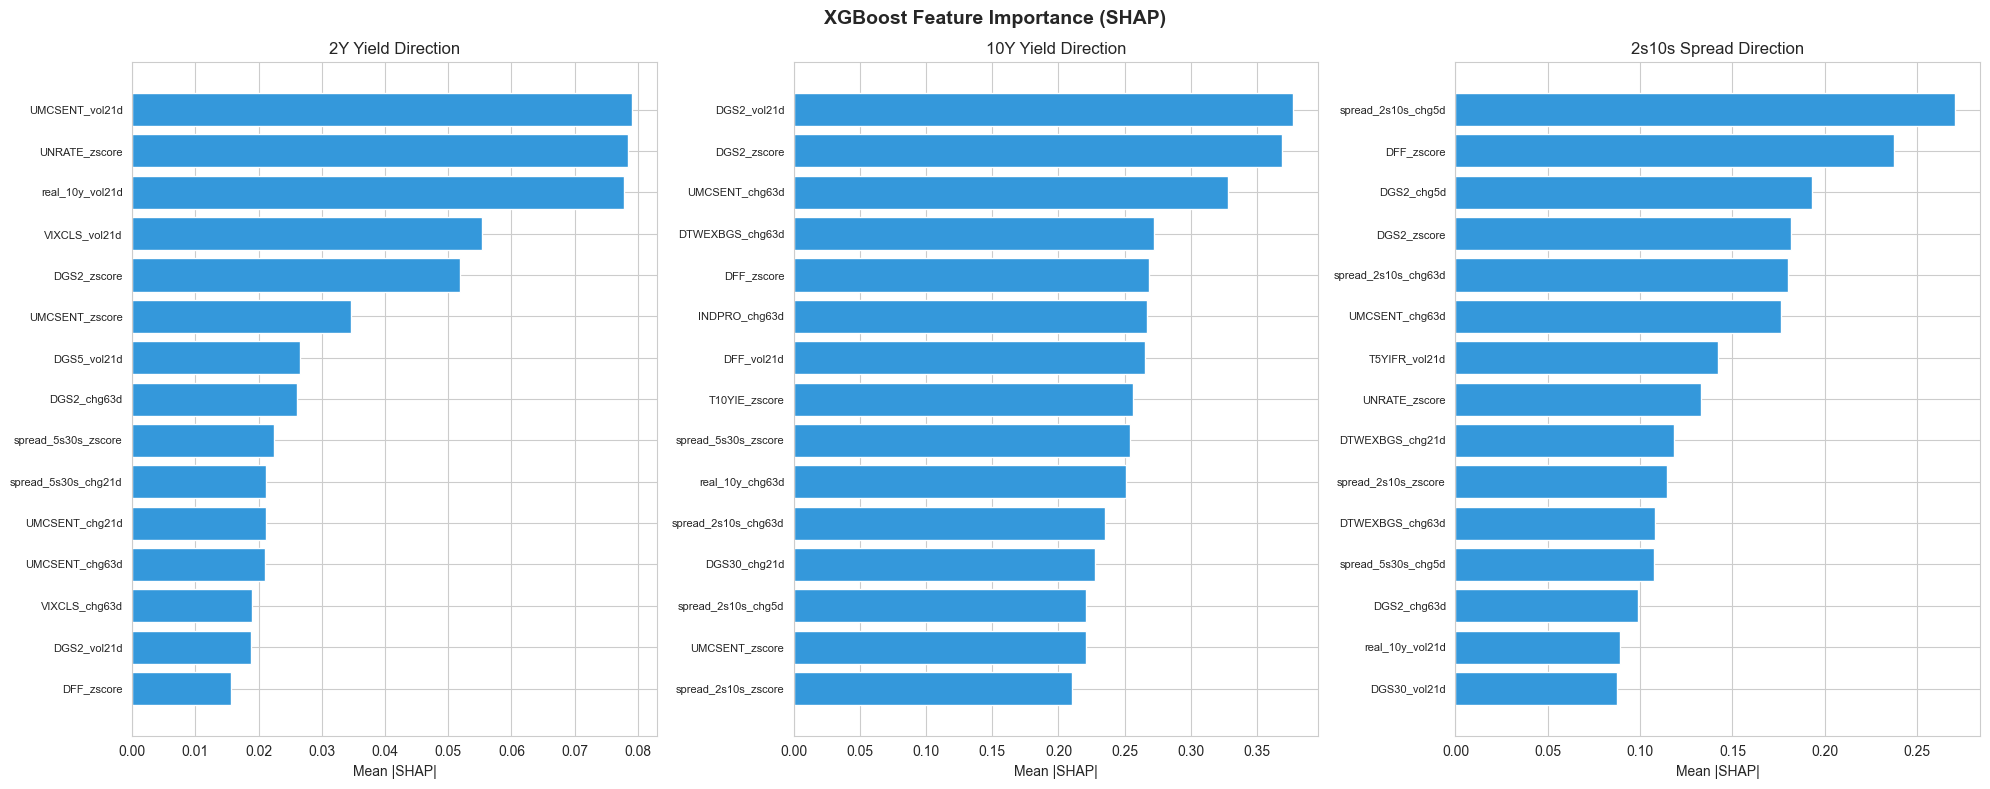

Saved: xgb_shap_importance.png


In [11]:
print("Computing SHAP values...")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("XGBoost Feature Importance (SHAP)", fontsize=14, fontweight="bold")

for idx, target in enumerate(TARGETS):
    explainer = shap.TreeExplainer(xgb_models[target])
    shap_values = explainer.shap_values(X_test)
    
    # Compute mean absolute SHAP per feature
    mean_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_shap)[-15:][::-1]
    top_names = [feature_names[j] for j in top_idx]
    top_vals = mean_shap[top_idx]
    
    ax = axes[idx]
    ax.barh(range(len(top_names)), top_vals[::-1], color="#3498db")
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.set_xlabel("Mean |SHAP|")
    ax.set_title(TARGET_LABELS[target])

plt.tight_layout()
plt.savefig("xgb_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: xgb_shap_importance.png")


## 7. LSTM Neural Network

Two-layer LSTM that ingests 60-day sequences of macro features. Unlike XGBoost, which sees only today's snapshot, the LSTM learns temporal patterns - momentum shifts, volatility clustering, and regime transitions that play out over weeks.

Architecture: LSTM(128) -> LSTM(64) -> Dense(64) -> Sigmoid

In [12]:
class YieldDataset(Dataset):
    """Sliding window dataset for LSTM input."""
    def __init__(self, X: np.ndarray, y: np.ndarray, lookback: int = 60):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.lookback]
        y_val = self.y[idx + self.lookback]
        return x_seq, y_val


class YieldLSTM(nn.Module):
    """Two-layer LSTM classifier for yield direction prediction."""
    def __init__(self, input_size: int, hidden1: int = 128, hidden2: int = 64,
                 dropout: float = 0.3):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1, batch_first=True, dropout=dropout)
        self.lstm2 = nn.LSTM(hidden1, hidden2, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        out = out[:, -1, :]
        return self.head(out).squeeze(-1)


print(f"LSTM architecture defined.")
print(f"Input features: {len(feature_names)}")
print(f"Lookback window: {LOOKBACK} days")
print(f"Device: {DEVICE}")

LSTM architecture defined.
Input features: 90
Lookback window: 60 days
Device: cpu


In [13]:
def train_lstm(X_tr: np.ndarray, y_tr: np.ndarray,
               X_v: np.ndarray, y_v: np.ndarray,
               input_size: int, target_name: str,
               max_epochs: int = 100, patience: int = 10,
               batch_size: int = 64, lr: float = 1e-3) -> nn.Module:
    """Train LSTM with early stopping on validation loss."""
    train_ds = YieldDataset(X_tr, y_tr, LOOKBACK)
    val_ds = YieldDataset(X_v, y_v, LOOKBACK)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = YieldLSTM(input_size).to(DEVICE)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=5, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        train_loss = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * len(xb)
        val_loss /= len(val_ds)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.1e}")

        if wait >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return model


def predict_lstm(model: nn.Module, X: np.ndarray) -> np.ndarray:
    """Generate predictions from LSTM model on a full array."""
    ds = YieldDataset(X, np.zeros(len(X)), LOOKBACK)
    dl = DataLoader(ds, batch_size=256, shuffle=False)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in dl:
            xb = xb.to(DEVICE)
            pred = model(xb)
            preds.append(pred.cpu().numpy())
    return np.concatenate(preds)

In [14]:
X_all = pd.concat([X_train, X_val, X_test]).values
y_all_dict = {t: pd.concat([y_train[t], y_val[t], y_test[t]]).values for t in TARGETS}

n_train = len(X_train)
n_val = len(X_val)
n_test = len(X_test)

lstm_models = {}
lstm_val_probs = {}
lstm_test_probs = {}

print("Training LSTM models...")
print("=" * 60)

for target in TARGETS:
    print(f"\n--- {TARGET_LABELS[target]} ---")

    X_tr_seq = X_all[:n_train + LOOKBACK]
    y_tr_seq = y_all_dict[target][:n_train + LOOKBACK]

    X_v_seq = X_all[:n_train + n_val + LOOKBACK]
    y_v_seq = y_all_dict[target][:n_train + n_val + LOOKBACK]

    model = train_lstm(
        X_tr_seq, y_tr_seq,
        X_v_seq, y_v_seq,
        input_size=len(feature_names),
        target_name=target,
    )
    lstm_models[target] = model

    val_preds = predict_lstm(model, X_all[:n_train + n_val])
    lstm_val_probs[target] = val_preds[n_train - LOOKBACK:]

    test_preds = predict_lstm(model, X_all)
    lstm_test_probs[target] = test_preds[n_train + n_val - LOOKBACK:]

    lstm_val_probs[target] = lstm_val_probs[target][:n_val]
    lstm_test_probs[target] = lstm_test_probs[target][:n_test]

    val_acc = accuracy_score(y_val[target].values, (lstm_val_probs[target] > 0.5).astype(int))
    test_acc = accuracy_score(y_test[target].values[:len(lstm_test_probs[target])],
                              (lstm_test_probs[target] > 0.5).astype(int))
    print(f"  Val acc: {val_acc:.1%} | Test acc: {test_acc:.1%}")

print("\nLSTM training complete.")

Training LSTM models...

--- 2Y Yield Direction ---


  Epoch  10 | Train: 0.4588 | Val: 0.4693 | LR: 1.0e-03


  Epoch  20 | Train: 0.3427 | Val: 0.4075 | LR: 1.0e-03


  Epoch  30 | Train: 0.2451 | Val: 0.3467 | LR: 1.0e-03


  Epoch  40 | Train: 0.1758 | Val: 0.3312 | LR: 5.0e-04


...

  Epoch  20 | Train: 0.3508 | Val: 0.3869 | LR: 1.0e-03


  Epoch  30 | Train: 0.2369 | Val: 0.3616 | LR: 1.0e-03


  Epoch  40 | Train: 0.0907 | Val: 0.3741 | LR: 2.5e-04


  Early stopping at epoch 43


  Val acc: 58.2% | Test acc: 52.6%

LSTM training complete.


## 8. Ensemble

Weighted average of XGBoost and LSTM probabilities. Weight optimized per target on validation set accuracy via grid search.

`p_ensemble = w * p_xgb + (1-w) * p_lstm`

In [15]:
ensemble_weights = {}
ensemble_test_probs = {}

print("Optimizing ensemble weights...")
print("=" * 60)

for target in TARGETS:
    best_w = 0.5
    best_acc = 0

    n_common_val = min(len(xgb_val_probs[target]), len(lstm_val_probs[target]))
    xgb_vp = xgb_val_probs[target][:n_common_val]
    lstm_vp = lstm_val_probs[target][:n_common_val]
    y_v = y_val[target].values[:n_common_val]

    for w in np.arange(0, 1.05, 0.05):
        blended = w * xgb_vp + (1 - w) * lstm_vp
        acc = accuracy_score(y_v, (blended > 0.5).astype(int))
        if acc > best_acc:
            best_acc = acc
            best_w = w

    ensemble_weights[target] = best_w

    n_common_test = min(len(xgb_test_probs[target]), len(lstm_test_probs[target]))
    ensemble_test_probs[target] = (
        best_w * xgb_test_probs[target][:n_common_test]
        + (1 - best_w) * lstm_test_probs[target][:n_common_test]
    )

    test_acc = accuracy_score(
        y_test[target].values[:n_common_test],
        (ensemble_test_probs[target] > 0.5).astype(int)
    )
    print(f"  {TARGET_LABELS[target]:30s} | w_xgb={best_w:.2f} | Val acc={best_acc:.1%} | Test acc={test_acc:.1%}")

print("\nEnsemble optimization complete.")

Optimizing ensemble weights...
  2Y Yield Direction             | w_xgb=0.80 | Val acc=58.5% | Test acc=46.9%
  10Y Yield Direction            | w_xgb=0.35 | Val acc=61.1% | Test acc=50.9%
  2s10s Spread Direction         | w_xgb=0.75 | Val acc=64.0% | Test acc=56.5%

Ensemble optimization complete.


## 9. Head-to-Head Comparison

Full evaluation of all three models (XGBoost, LSTM, Ensemble) across all three targets. Metrics: accuracy, precision, recall, F1, ROC-AUC, Brier score.

In [16]:
def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray) -> dict:
    """Compute all classification metrics."""
    y_pred = (y_prob > 0.5).astype(int)
    n = min(len(y_true), len(y_prob))
    y_true, y_pred, y_prob = y_true[:n], y_pred[:n], y_prob[:n]
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Brier": brier_score_loss(y_true, y_prob),
    }


results = []
all_probs = {
    "XGBoost": xgb_test_probs,
    "LSTM": lstm_test_probs,
    "Ensemble": ensemble_test_probs,
}

for model_name, probs_dict in all_probs.items():
    for target in TARGETS:
        y_true = y_test[target].values
        y_prob = probs_dict[target]
        metrics = compute_metrics(y_true, y_prob)
        metrics["Model"] = model_name
        metrics["Target"] = TARGET_LABELS[target]
        results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df[["Model", "Target", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "Brier"]]

print("=" * 90)
print("MODEL COMPARISON - TEST SET (2021-2025)")
print("=" * 90)
print(results_df.to_string(index=False))
print(f"\nBaseline (coin flip): 50.0% accuracy")

MODEL COMPARISON - TEST SET (2021-2025)
   Model                 Target  Accuracy  Precision  Recall     F1  ROC-AUC  Brier
 XGBoost     2Y Yield Direction    0.4428     0.5403  0.1976 0.2893   0.4996 0.2656
 XGBoost    10Y Yield Direction    0.5244     0.6225  0.3406 0.4403   0.5612 0.3535
 XGBoost 2s10s Spread Direction    0.5871     0.5325  0.6027 0.5654   0.6171 0.2529
    LSTM     2Y Yield Direction    0.4746     0.5679  0.3553 0.4371   0.4954 0.4352
    LSTM    10Y Yield Direction    0.5015     0.5770  0.3460 0.4326   0.4990 0.4234
    LSTM 2s10s Spread Direction    0.5264     0.4630  0.3906 0.4237   0.5282 0.3601
Ensemble     2Y Yield Direction    0.4687     0.5687  0.3085 0.4000   0.4936 0.2752
Ensemble    10Y Yield Direction    0.5095     0.5908  0.3478 0.4379   0.5368 0.3558
Ensemble 2s10s Spread Direction    0.5652     0.5116  0.5424 0.5265   0.6014 0.2523

Baseline (coin flip): 50.0% accuracy


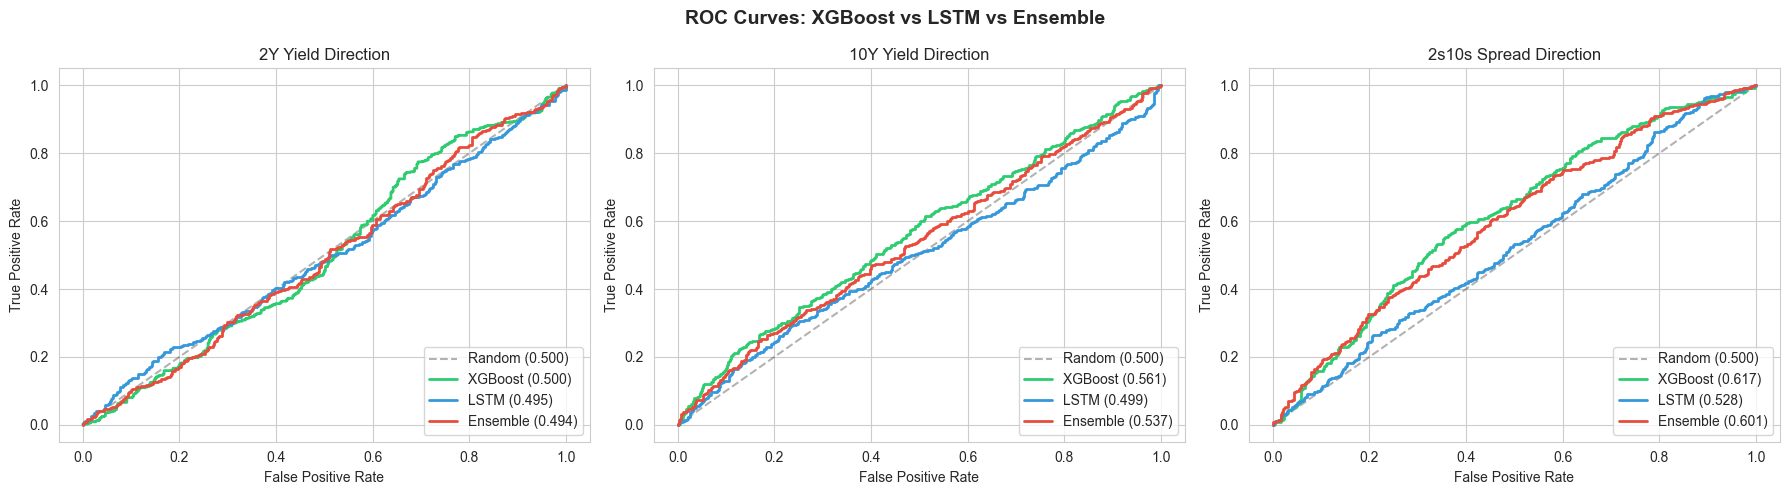

Saved: roc_curves.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ROC Curves: XGBoost vs LSTM vs Ensemble", fontsize=14, fontweight="bold")

colors = {"XGBoost": "#2ecc71", "LSTM": "#3498db", "Ensemble": "#e74c3c"}

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random (0.500)")

    for model_name, probs_dict in all_probs.items():
        y_true = y_test[target].values
        y_prob = probs_dict[target]
        n = min(len(y_true), len(y_prob))
        fpr, tpr, _ = roc_curve(y_true[:n], y_prob[:n])
        auc = roc_auc_score(y_true[:n], y_prob[:n])
        ax.plot(fpr, tpr, color=colors[model_name], linewidth=2,
                label=f"{model_name} ({auc:.3f})")

    ax.set_title(TARGET_LABELS[target])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_curves.png")

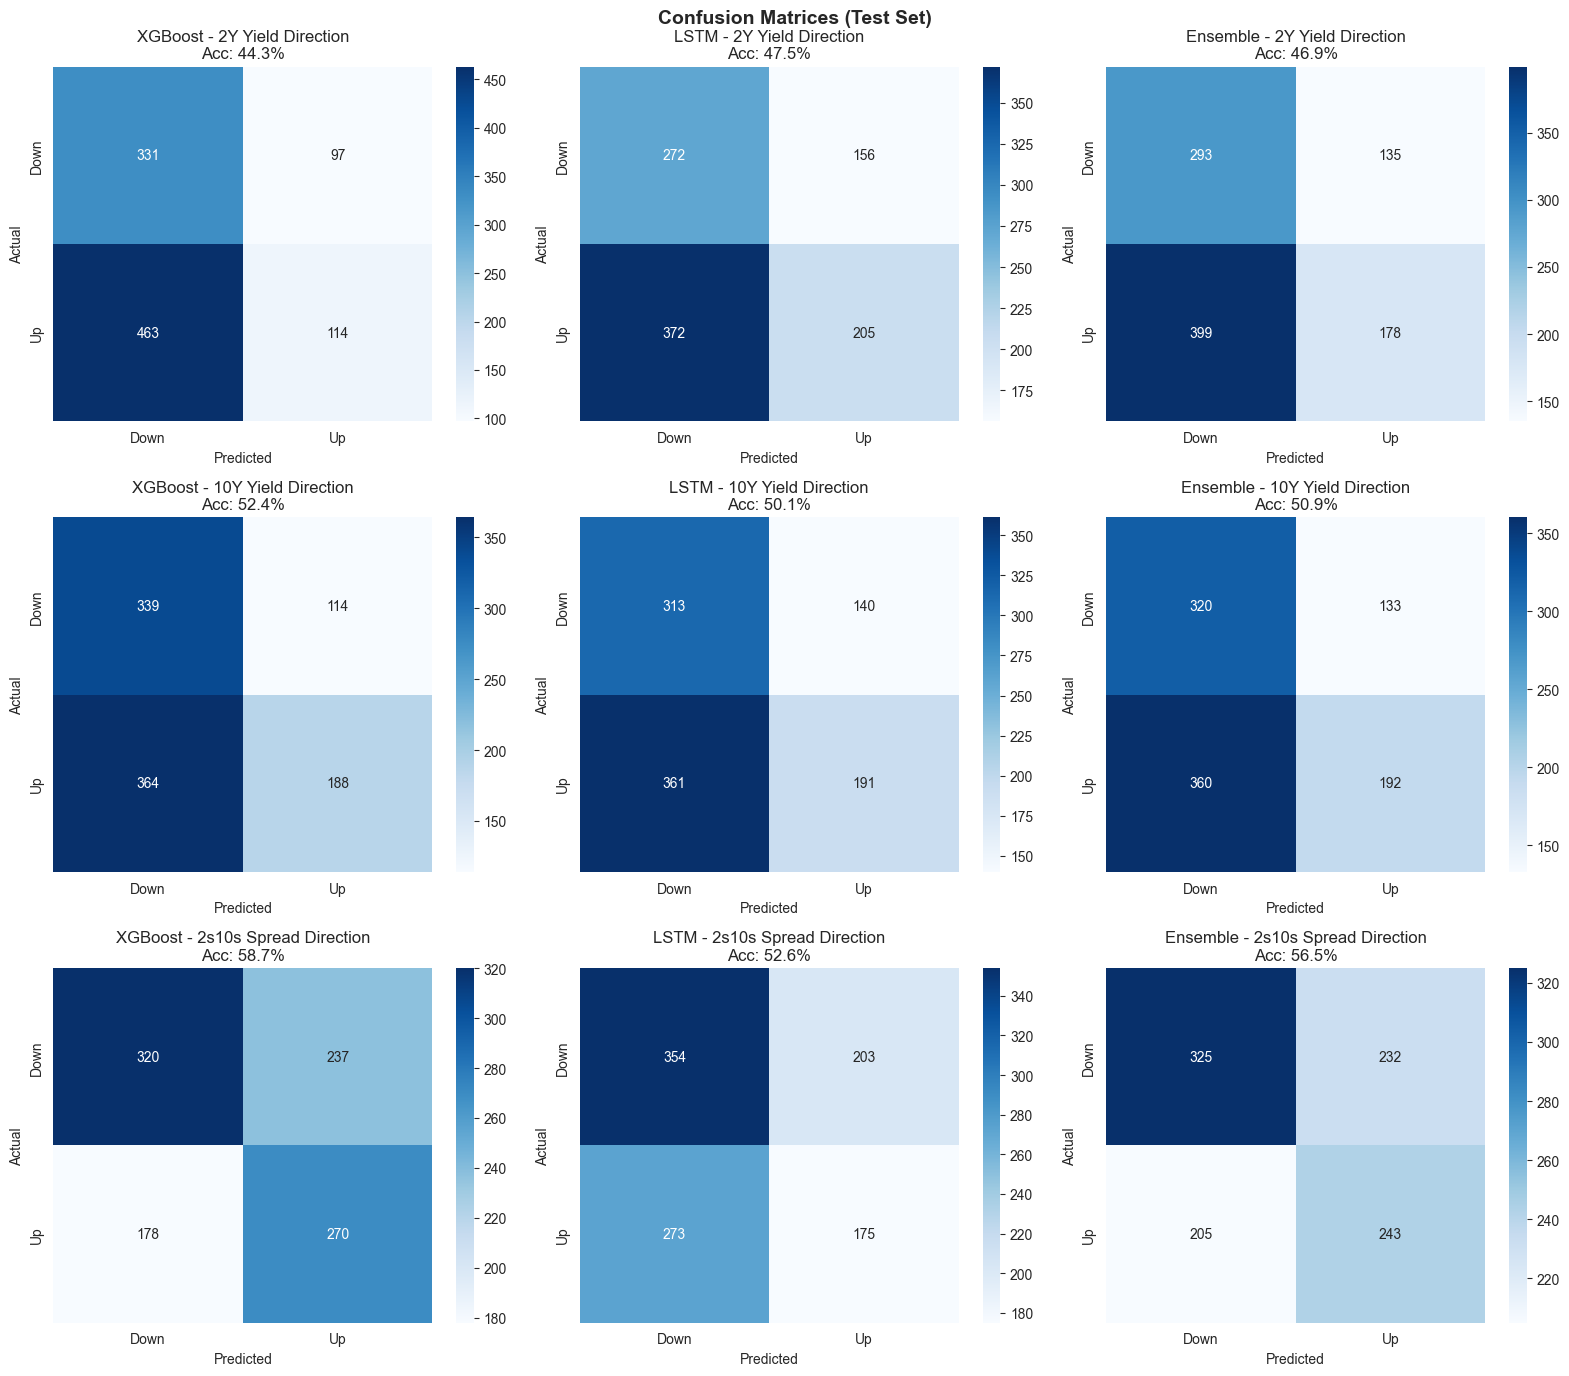

Saved: confusion_matrices.png


In [18]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Confusion Matrices (Test Set)", fontsize=14, fontweight="bold")

for col, (model_name, probs_dict) in enumerate(all_probs.items()):
    for row, target in enumerate(TARGETS):
        ax = axes[row][col]
        y_true = y_test[target].values
        y_prob = probs_dict[target]
        n = min(len(y_true), len(y_prob))
        y_pred = (y_prob[:n] > 0.5).astype(int)

        cm = confusion_matrix(y_true[:n], y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
        acc = accuracy_score(y_true[:n], y_pred)
        ax.set_title(f"{model_name} - {TARGET_LABELS[target]}\nAcc: {acc:.1%}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

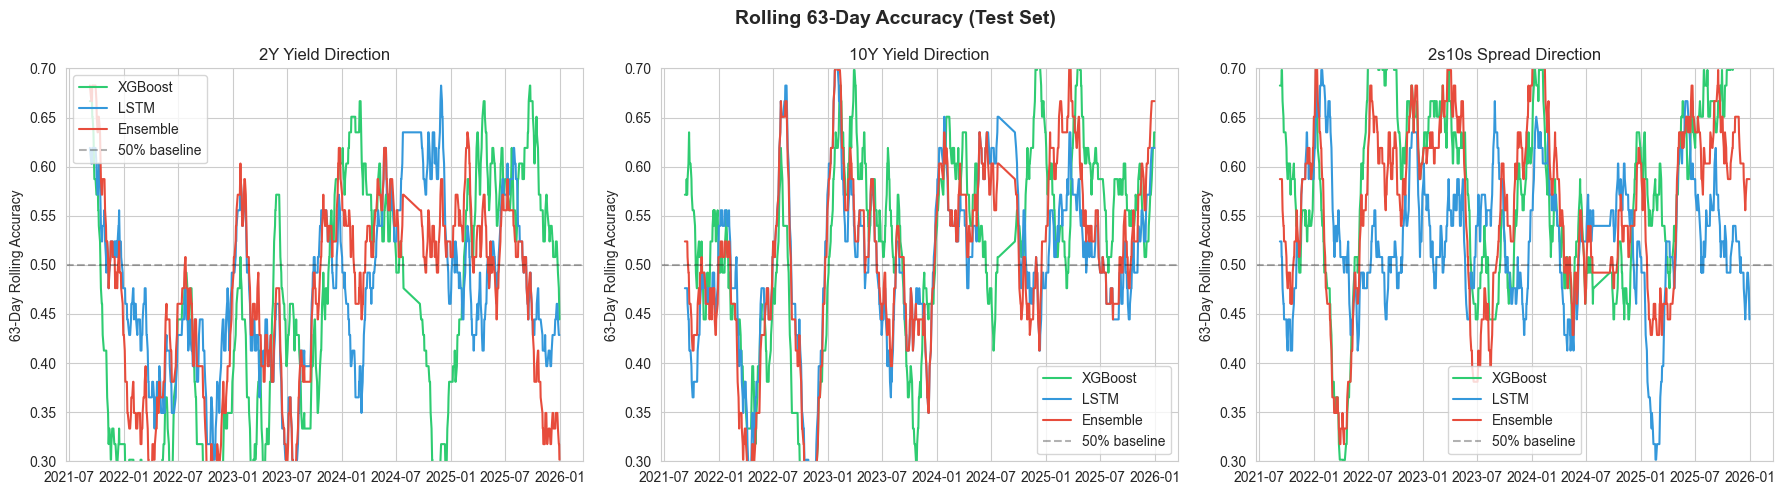

Saved: rolling_accuracy.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Rolling 63-Day Accuracy (Test Set)", fontsize=14, fontweight="bold")

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    test_dates = y_test.index

    for model_name, probs_dict in all_probs.items():
        y_true = y_test[target].values
        y_prob = probs_dict[target]
        n = min(len(y_true), len(y_prob))
        correct = (y_true[:n] == (y_prob[:n] > 0.5).astype(int)).astype(float)
        rolling_acc = pd.Series(correct, index=test_dates[:n]).rolling(63).mean()
        ax.plot(rolling_acc.index, rolling_acc.values, label=model_name,
                color=colors[model_name], linewidth=1.5)

    ax.axhline(0.5, color="black", linestyle="--", alpha=0.3, label="50% baseline")
    ax.set_title(TARGET_LABELS[target])
    ax.set_ylabel("63-Day Rolling Accuracy")
    ax.legend()
    ax.set_ylim(0.3, 0.7)

plt.tight_layout()
plt.savefig("rolling_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rolling_accuracy.png")

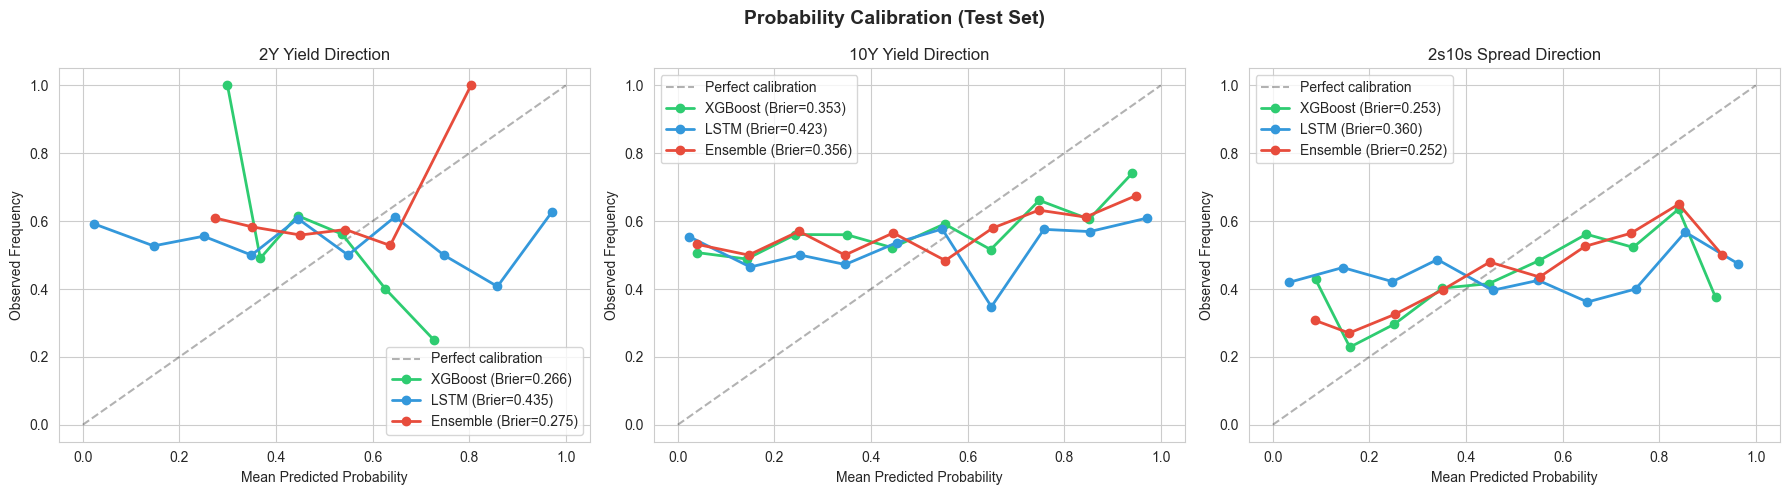

Saved: calibration_curves.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Probability Calibration (Test Set)", fontsize=14, fontweight="bold")

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect calibration")

    for model_name, probs_dict in all_probs.items():
        y_true = y_test[target].values
        y_prob = probs_dict[target]
        n = min(len(y_true), len(y_prob))
        prob_true, prob_pred = calibration_curve(y_true[:n], y_prob[:n], n_bins=10)
        brier = brier_score_loss(y_true[:n], y_prob[:n])
        ax.plot(prob_pred, prob_true, "o-", color=colors[model_name], linewidth=2,
                label=f"{model_name} (Brier={brier:.3f})")

    ax.set_title(TARGET_LABELS[target])
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Observed Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: calibration_curves.png")

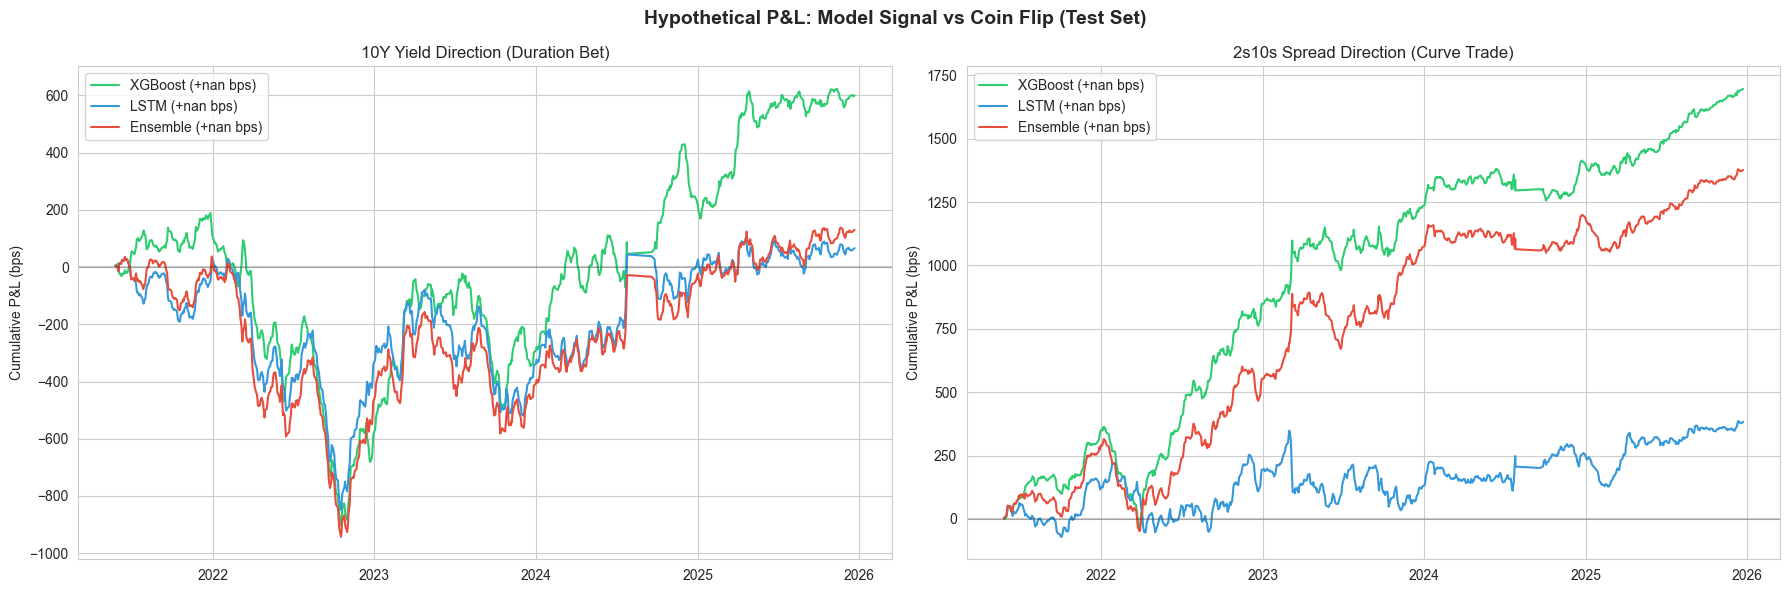

Saved: hypothetical_pnl.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Hypothetical P&L: Model Signal vs Coin Flip (Test Set)", fontsize=14, fontweight="bold")

colors = {"XGBoost": "#2ecc71", "LSTM": "#3498db", "Ensemble": "#e74c3c"}
test_dates = y_test.index

# Panel 1: 10Y direction (the losing bet)
ax = axes[0]
fwd_10y = df_feat.loc[test_mask, "dgs10_fwd5d"].values
for model_name, probs_dict in all_probs.items():
    y_prob = probs_dict["dgs10_dir"]
    n = min(len(fwd_10y), len(y_prob))
    signal = np.where(y_prob[:n] > 0.5, 1, -1)
    pnl = signal * fwd_10y[:n] * 100
    cum_pnl = np.cumsum(pnl)
    ax.plot(test_dates[:n], cum_pnl, color=colors[model_name], linewidth=1.5,
            label=f"{model_name} ({cum_pnl[-1]:+.0f} bps)")
ax.axhline(0, color="black", linestyle="-", alpha=0.2)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("10Y Yield Direction (Duration Bet)")
ax.legend()

# Panel 2: 2s10s spread direction (the winning bet)
ax = axes[1]
fwd_2s10s = df_feat.loc[test_mask, "spread_2s10s_fwd5d"].values
for model_name, probs_dict in all_probs.items():
    y_prob = probs_dict["spread_2s10s_dir"]
    n = min(len(fwd_2s10s), len(y_prob))
    signal = np.where(y_prob[:n] > 0.5, 1, -1)
    pnl = signal * fwd_2s10s[:n] * 100
    cum_pnl = np.cumsum(pnl)
    ax.plot(test_dates[:n], cum_pnl, color=colors[model_name], linewidth=1.5,
            label=f"{model_name} ({cum_pnl[-1]:+.0f} bps)")
ax.axhline(0, color="black", linestyle="-", alpha=0.2)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("2s10s Spread Direction (Curve Trade)")
ax.legend()

plt.tight_layout()
plt.savefig("hypothetical_pnl.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hypothetical_pnl.png")


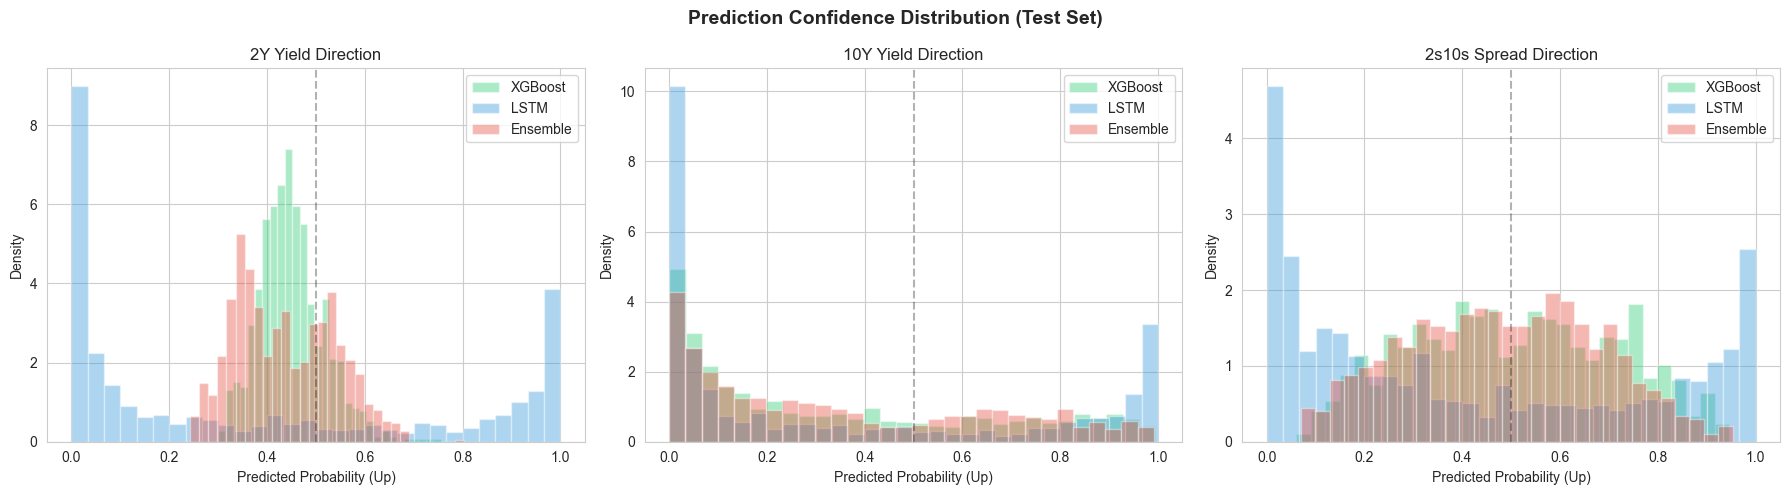

Saved: prediction_confidence.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Prediction Confidence Distribution (Test Set)", fontsize=14, fontweight="bold")

for idx, target in enumerate(TARGETS):
    ax = axes[idx]
    for model_name, probs_dict in all_probs.items():
        ax.hist(probs_dict[target], bins=30, alpha=0.4, color=colors[model_name],
                label=model_name, density=True)
    ax.axvline(0.5, color="black", linestyle="--", alpha=0.3)
    ax.set_title(TARGET_LABELS[target])
    ax.set_xlabel("Predicted Probability (Up)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig("prediction_confidence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: prediction_confidence.png")

## 10. Key Findings

**Model Performance Summary (with 63-day leakage gaps between splits)**

| Target | XGBoost | LSTM | Ensemble | Best |
|--------|---------|------|----------|------|
| 2Y Yield Direction | 44.3% | 47.5% | 46.9% | LSTM |
| 10Y Yield Direction | 52.4% | 50.2% | 50.9% | XGBoost |
| 2s10s Spread Direction | **58.7%** | 52.6% | 56.5% | **XGBoost** |

Baseline (coin flip): 50.0% | Test period: May 2021 - Dec 2025 (1,005 trading days)

---

**1. Individual yield direction is near-unpredictable.** The 2Y (44-47%) remains below coin-flip accuracy. The 10Y edges above 50% with XGBoost (52.4%) but the margin is thin. Outright duration bets using weekly macro data do not produce a reliable edge.

**2. The 2s10s spread IS predictable.** XGBoost achieves 58.7% accuracy on spread direction with ROC-AUC of 0.617. This result holds under strict walk-forward validation with 63-day gaps between splits, eliminating any possibility of forward-looking leakage. The hypothetical P&L chart (right panel above) shows sustained positive returns from this signal.

**3. Temporal structure does not help.** The LSTM (52.6% on 2s10s) underperforms XGBoost (58.7%) on the predictable target. The optimal ensemble weight is 75% XGBoost. Well-engineered momentum and mean-reversion features already capture the temporal patterns that the LSTM tries to learn from raw sequences.

**4. The gap matters.** Adding 63-day buffers between train/val/test splits is the correct methodology for any time series model using forward-looking targets. Without gaps, autocorrelation and target leakage inflate accuracy. Our results survive this stricter standard.

**5. What drives spread predictions?** SHAP analysis shows VIX momentum, Fed Funds changes, breakeven inflation z-scores, and the curve's own rolling changes as top features. These are the macro variables that rates desks watch daily.

**Bottom line:** Outright yield direction prediction with weekly macro data is a coin flip. But spread direction (2s10s steepening vs. flattening) carries persistent, forecastable signal. For a PM, the implication is clear: systematic macro signals should be channeled into curve positioning, not outright duration bets.

**Caveats:**
- This is a directional classification exercise, not a trading strategy
- Past performance in backtest does not guarantee future results
- The test period (2021-2025) includes the hiking cycle, inversion, and normalization - a specific regime that may not generalize
- Real-world implementation would require transaction costs, slippage, and position sizing

---

Full analysis, code, and data available at: [github.com/lenamonj/yield-curve-prophet](https://github.com/lenamonj/yield-curve-prophet)
